In [25]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict
from IPython.display import Image , display
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

True

In [13]:
##BMI CALCULATOR

In [27]:
model = ChatOpenAI()

In [19]:
class BMIState(TypedDict):
    weight_kg: float
    height_m : float
    bmi : float
    category : str

In [15]:
def calculate_bmi(state:BMIState)-> BMIState:
    state['bmi'] = state['weight_kg'] / (state['height_m'] ** 2)
    return state

In [20]:
def label_BMI(state:BMIState)-> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

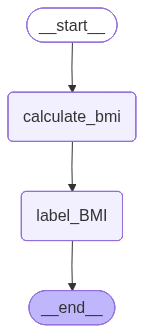

In [21]:
graph = StateGraph(BMIState)
#add nodes
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_BMI' , label_BMI)

#ADD EDGES
graph.add_edge(START , 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_BMI')
graph.add_edge('label_BMI', END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [23]:
graph_builder.invoke({
    'weight_kg': 88,
    'height_m': 1.95
})

{'weight_kg': 88,
 'height_m': 1.95,
 'bmi': 23.14266929651545,
 'category': 'Normal weight'}

In [26]:
#State

class LLMState(TypedDict):
    question : str
    answer : str

In [28]:
def llm_qa(state:LLMState)-> LLMState:
    question = state['question']
    prompt = f'Answer the following question: {question}'
    answer = model.invoke(prompt).content
    state['answer'] = answer
    return state

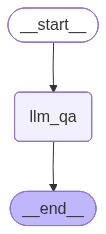

In [29]:
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)
graph.add_edge(START , 'llm_qa')
graph.add_edge('llm_qa', END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [30]:
initial_state = {'question': 'How far is the moon from the EARTH'}

final_state = graph_builder.invoke(initial_state)

print(final_state)

{'question': 'How far is the moon from the EARTH', 'answer': 'The average distance from the Earth to the Moon is about 384,400 kilometers (238,855 miles).'}


In [31]:
#Blog Generation
class BlogState(TypedDict):
    topic:str
    outline:str
    content:str
    

In [32]:
def create_outline(state:BlogState)->BlogState:
    topic = state['topic']

    prompt = f"Generate a outline for a blog for the topic - {topic}"

    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [33]:
def create_blog(state:BlogState)->BlogState:
    outline = state['outline']
    topic = state['topic']

    prompt = f"Write a blog on the topic - {topic} using the following outline - {outline}"

    content = model.invoke(prompt).content
    state['content'] = content
    return state

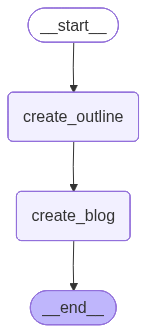

In [35]:
graph = StateGraph(BlogState)
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START , 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [37]:
initial_State = {'topic': 'Rise of AI worldwide'}

final_state = graph_builder.invoke(initial_State)

print(final_state['content'])

The Rise of AI Worldwide

I. Introduction
Artificial Intelligence (AI) has become an increasingly prevalent and transformative technology worldwide. Its rapid advancement is reshaping various industries and fundamentally changing the way we live and work. From healthcare to finance, transportation to manufacturing, AI is revolutionizing processes, enhancing efficiency, and unlocking new possibilities.

II. History of AI
The history of AI dates back to the 1950s when the term was first coined. Since then, there have been significant developments and breakthroughs in the field, including the creation of neural networks, machine learning algorithms, and deep learning models. Key milestones such as IBM's Deep Blue defeating a world chess champion and Google's AlphaGo mastering the ancient game of Go have demonstrated the power and potential of AI technology.

III. Applications of AI
AI is being applied across various industries to improve outcomes and streamline operations. In healthcare, 